# Гистограммы

In [75]:
import numpy as np
import math
import random
import sympy
import matplotlib.pyplot as plt

In [76]:
hist=np.array([1,1,3,4,6,7,7,9,8,8,7,6,6,4,4,2,1])
sum_hist=sum(hist)

In [77]:
P=[]
pred=0
for his in hist:
    newh=round(pred+his/sum_hist,3)
    P.append((pred,round(newh-0.001,3)))
    pred=newh
P[-1]=(P[-1][0],1)
for i in P:       
    print(i)

(0, np.float64(0.011))
(np.float64(0.012), np.float64(0.023))
(np.float64(0.024), np.float64(0.059))
(np.float64(0.06), np.float64(0.107))
(np.float64(0.108), np.float64(0.178))
(np.float64(0.179), np.float64(0.261))
(np.float64(0.262), np.float64(0.344))
(np.float64(0.345), np.float64(0.451))
(np.float64(0.452), np.float64(0.546))
(np.float64(0.547), np.float64(0.641))
(np.float64(0.642), np.float64(0.724))
(np.float64(0.725), np.float64(0.795))
(np.float64(0.796), np.float64(0.866))
(np.float64(0.867), np.float64(0.914))
(np.float64(0.915), np.float64(0.962))
(np.float64(0.963), np.float64(0.986))
(np.float64(0.987), 1)


[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


C:\Users\anton\AppData\Local\Temp\ipykernel_17100\3209660039.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(x_pos)


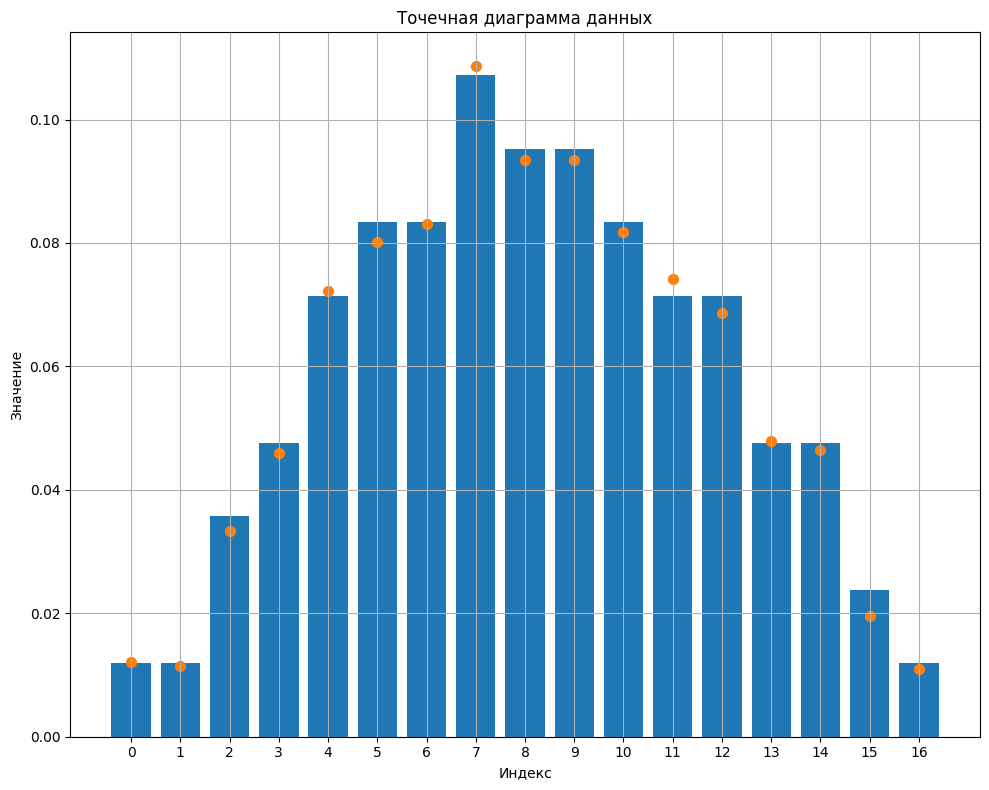

In [78]:
def calculate_percentage(x, x_min, x_max):
    return (((x - x_min) / (x_max - x_min))-0.5)
new_graf1=np.zeros(len(hist))
new_graf1[1]+=1
print(new_graf1)
new_graf=[]
rval=0.0
x=0
for _ in range(10000):
    rval=random.uniform(0,1)
    for p in P:
        if p[0]<=rval<=p[1]:
            index=P.index(p)
            new_graf1[index]+=1
            x=index+random.randrange(int(p[0]*1000),int(p[1]*1000))/1000
            new_graf.append((x,hist[index]))
        else:
            continue
# new_graf= sorted(new_graf, key=lambda x: x[1])
# for i in new_graf:       
#     print(i)

x_pos = np.arange(len(hist))  # Позиции столбцов на оси X

# Создаем фигуру с двумя subplots (один над другим)
fig, axes = plt.subplots(1, 1, figsize=(10, 8))

# Нижний график - столбчатая гистограмма
axes.bar(x_pos, hist/sum_hist, width=0.8, align='center')

axes.set_xticklabels(x_pos)
axes.set_xlabel("Индекс")
axes.set_ylabel("Частота")
axes.set_title("Столбчатая гистограмма")
axes.grid(True)
x_points, y_points = range(len(new_graf1)),new_graf1/10000
axes.scatter(x_points, y_points, s=50, alpha=1)
axes.set_xticks(x_pos)
axes.set_xticklabels(x_pos)
axes.set_xlabel("Индекс")
axes.set_ylabel("Значение")
axes.set_title("Точечная диаграмма данных")
axes.grid(True)
# Настраиваем расстояние между графиками
plt.tight_layout()
plt.show()

# Карты

In [79]:
cards=["6","7","8","9","10","Валет","Дама","Король","Туз"]
coloda={"Крести ♣":cards.copy(),
        "Пики ♠":cards.copy(),
        "Червы ♥":cards.copy(),
        "Буби ♦":cards.copy()}

    
def get_P():
    P=[]
    count=0
    pred=0
    for i in coloda.values():
        count+=len(i)
    for i in coloda.values():
        newh=round(pred+len(i)/count,3)
        P.append([pred,newh])
        pred=newh
    
    Pcard=[]


    for i in coloda.values():
        u=[]
        pred=0
        for j in i:
            newh=round(pred+1.0/len(i),4)
            u.append([pred,newh])
            pred=newh
        if u:
            u[-1][1]=1
        Pcard.append(u)
    
    return P,Pcard,count

P,Pcard, count = get_P()
random_coloda=[]
while (count>1):
    P,Pcard, count = get_P()
    rval=random.uniform(0,1)
    for p in P:
        if p[0]<=rval<=p[1]:
                index=P.index(p)
                rval=random.uniform(0,1)
                for v in Pcard[index]:
                    if v[0]<=rval<=v[1]:
                        index1=Pcard[index].index(v)
                        x=index+calculate_percentage(rval,p[0],p[1])
                        key1=list(coloda.keys())[index]
                        random_coloda.append(f"{coloda[key1][index1]} {key1}")
                        coloda[key1].remove(coloda[key1][index1])
                        break
                    else:
                        continue
                break
        else:
            continue
print(random_coloda)
print(len(random_coloda))

['9 Пики ♠', '7 Крести ♣', '6 Буби ♦', 'Валет Крести ♣', '8 Пики ♠', '10 Червы ♥', '6 Пики ♠', 'Дама Крести ♣', '7 Червы ♥', '7 Пики ♠', 'Король Пики ♠', '8 Буби ♦', 'Король Червы ♥', '10 Крести ♣', '9 Буби ♦', 'Валет Пики ♠', 'Дама Пики ♠', 'Дама Червы ♥', 'Дама Буби ♦', '7 Буби ♦', '8 Крести ♣', '8 Червы ♥', 'Король Буби ♦', '10 Буби ♦', 'Туз Буби ♦', 'Валет Буби ♦', 'Валет Червы ♥', 'Туз Пики ♠', '9 Червы ♥', '10 Пики ♠', 'Туз Крести ♣', '6 Крести ♣', 'Король Крести ♣', 'Туз Червы ♥', '6 Червы ♥', '9 Крести ♣']
36


# Резисторы

In [80]:
sum_F1=0
sum_F2=0
R=20
for i in range(1000):
    rq1_seq=random.normalvariate(10,1)
    rq2_seq=random.normalvariate(10,1)
    r_res1=rq1_seq+rq2_seq
    # print(r_res1)
    sum_F1+=(r_res1-R)**2
    
    rq1_paral=random.normalvariate(40,5)
    rq2_paral=random.normalvariate(40,5)
    r_res2=(rq1_paral*rq2_paral)/(rq1_paral+rq2_paral)
    
    # print(r_res2)
    sum_F2+=(r_res2-R)**2
print(sum_F1,sum_F2)
print((sum_F1/(1000-2+1))**0.5,(sum_F2/(1000-2+1))**0.5)


2036.1290001502064 3090.7367437551393
1.427643921752733 1.7589288144576714


Ошибка для последовательной схемы: 20129.57
Ошибка для параллельной схемы: 32549.23
Сигма (стандартное отклонение) для последовательной схемы: 1.4189
Сигма (стандартное отклонение) для параллельной схемы: 1.8042


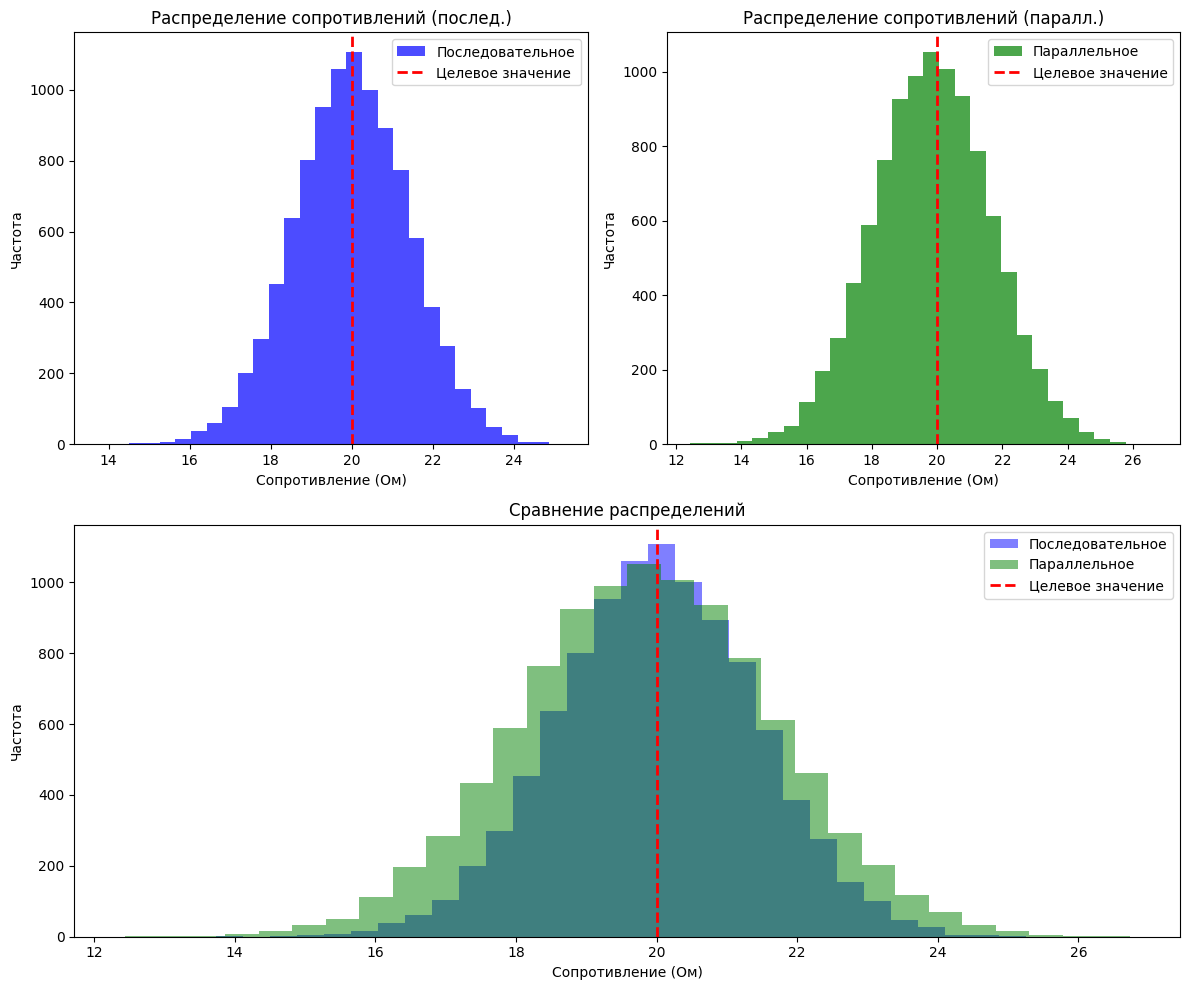

In [81]:
import random
import matplotlib.pyplot as plt
import numpy as np

R = 20  # Целевое значение сопротивления
n = 10000

errors_F1 = []
errors_F2 = []
r1_values = []
r2_values = []

for i in range(n):
    rq1_seq = random.normalvariate(10, 1)
    rq2_seq = random.normalvariate(10, 1)
    r_res1 = rq1_seq + rq2_seq
    r1_values.append(r_res1)
    errors_F1.append((r_res1 - R)**2)

    rq1_paral = random.normalvariate(40, 5)
    rq2_paral = random.normalvariate(40, 5)
    r_res2 = (rq1_paral * rq2_paral) / (rq1_paral + rq2_paral)
    r2_values.append(r_res2)
    errors_F2.append((r_res2 - R) ** 2)


sum_F1=sum(errors_F1)
sum_F2=sum(errors_F2)
sigma_F1 = (sum_F1 / (n - 2 + 1)) ** 0.5
sigma_F2 = (sum_F2 / (n - 2 + 1)) ** 0.5

print(f"Ошибка для последовательной схемы: {sum_F1:.2f}")
print(f"Ошибка для параллельной схемы: {sum_F2:.2f}")
print(f"Сигма (стандартное отклонение) для последовательной схемы: {sigma_F1:.4f}")
print(f"Сигма (стандартное отклонение) для параллельной схемы: {sigma_F2:.4f}")

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.hist(r1_values, bins=30, color='blue', alpha=0.7, label="Последовательное")
plt.axvline(R, color='red', linestyle='dashed', linewidth=2, label="Целевое значение")
plt.xlabel("Сопротивление (Ом)")
plt.ylabel("Частота")
plt.title("Распределение сопротивлений (послед.)")
plt.legend()
plt.subplot(2, 2, 2)
plt.hist(r2_values, bins=30, color='green', alpha=0.7, label="Параллельное")
plt.axvline(R, color='red', linestyle='dashed', linewidth=2, label="Целевое значение")
plt.xlabel("Сопротивление (Ом)")
plt.ylabel("Частота")
plt.title("Распределение сопротивлений (паралл.)")
plt.legend()
plt.subplot(2, 1, 2)
plt.hist(r1_values, bins=30, color='blue', alpha=0.5, label="Последовательное")
plt.hist(r2_values, bins=30, color='green', alpha=0.5, label="Параллельное")
plt.axvline(R, color='red', linestyle='dashed', linewidth=2, label="Целевое значение")
plt.xlabel("Сопротивление (Ом)")
plt.ylabel("Частота")
plt.title("Сравнение распределений")
plt.legend()
plt.tight_layout()
plt.show()


# 26 марта 2025 лабораторная

## танки

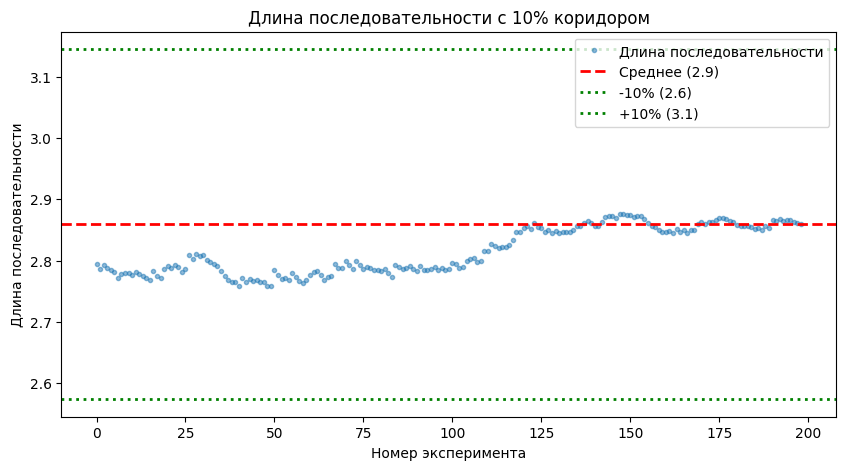

In [82]:
matrix_p=np.array([[0.45, 0.4, 0.15],
                  [0, 0.45, 0.55],
                  [0, 0.0, 1]])
matrix_p_inin=np.array([0.8, 0.2, 0])
matrix_p_inin=[(0,0.8),(0.8,1),(0,0)]
def test():
    otvet=[]
    index_s=0
    rval=random.uniform(0,1)
    for i in matrix_p_inin:
        if i[0]<=rval<i[1]:
            index_s=matrix_p_inin.index(i)            
        else:
            continue
    while(True):
        rval=random.uniform(0,1)
        pred=0
        for i in matrix_p[index_s]:
            new_pred=pred+i
            if pred<=rval<new_pred:
                index_s=list(matrix_p[index_s]).index(i)
                otvet.append(index_s)
                break
            else:
                pred=new_pred
                continue
        if index_s==2:
            break
    return otvet
# round(sum([len(test()) for _ in range(1000)])/1000)
# print(round(sum([len(test()) for _ in range(1000)])/1000,1))
# Запуск тестов и вычисление статистики
num_trials = 200
lengths = [len(test()) for i in range(1,num_trials)]
mean_lengths=[]
for i in range(1,num_trials):
    lengths.append(len(test()))
    mean_lengths.append(sum(lengths) / len(lengths))
mean_length=mean_lengths[-1]
# Определение границ коридора
lower_bound = mean_length * 0.9
upper_bound = mean_length * 1.1

# Построение графика
plt.figure(figsize=(10, 5))
plt.plot(mean_lengths, marker='.', linestyle='', alpha=0.5, label="Длина последовательности")
plt.axhline(mean_length, color='red', linestyle='dashed', linewidth=2, label=f"Среднее ({mean_length:.1f})")
plt.axhline(lower_bound, color='green', linestyle='dotted', linewidth=2, label=f"-10% ({lower_bound:.1f})")
plt.axhline(upper_bound, color='green', linestyle='dotted', linewidth=2, label=f"+10% ({upper_bound:.1f})")

plt.xlabel("Номер эксперимента")
plt.ylabel("Длина последовательности")
plt.title("Длина последовательности с 10% коридором")
plt.legend()
plt.show()

## Волейбол

{'[3, 0]': 86.741, '[3, 1]': 12.069, '[0, 3]': 0.009, '[1, 3]': 0.025, '[3, 2]': 1.103, '[2, 3]': 0.053}


C:\Users\anton\AppData\Local\Temp\ipykernel_17100\1621312847.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(dict_otvet.keys())


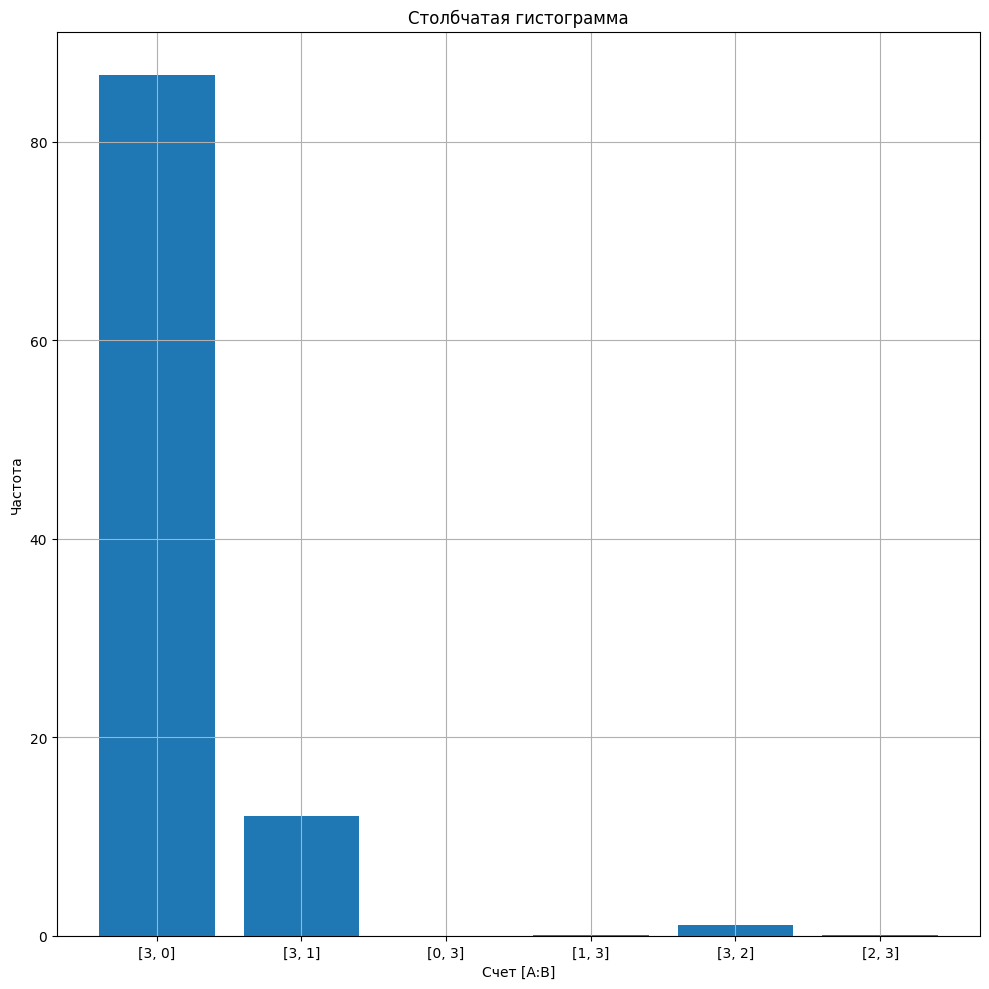

In [83]:
matrix_p_g=[[0.7, 0.3],[0.6, 0.4]]
def game(start=0,end_game=15,otvet1=[0,0]):
    otvet=otvet1
    index_s=start
    start+=1
    store=[0,0]  
    while(True):
        rval=random.uniform(0,1)
        pred=0
        for i in matrix_p_g[index_s]:
            new_pred=pred+i
            if pred<=rval<new_pred:
                index_s=matrix_p_g[index_s].index(i)
                store[index_s]+=1
                break
            else:
                pred=new_pred
                continue
        if (store[0]>=end_game or store[1]>=end_game):
            if store[0]>=end_game:
                otvet[0]+=1
            else:
                otvet[1]+=1
            break
    if otvet[0]>=3 or otvet[1]>=3:
        return otvet
    game(start=start%2,otvet1=otvet)
    
    return otvet

set_g=[game(0,15,[0,0])]
for i in range(1,100000):
    set_g.append(game(0,15,[0,0]))
dict_otvet={
    "[3, 0]":0,
    "[3, 1]":0,
    "[0, 3]":0,
    "[1, 3]":0,
    "[3, 2]":0,
    "[2, 3]":0
}
for i in set_g:
    key=f'{i}'
    dict_otvet[key]+=1

for i in dict_otvet.keys():
    dict_otvet[i]/=1000
print(dict_otvet)
x_pos = np.arange(len(dict_otvet))  # Позиции столбцов на оси X

# Создаем фигуру с двумя subplots (один над другим)
fig, axes = plt.subplots(1, 1, figsize=(10, 10))

# Нижний график - столбчатая гистограмма
axes.bar(dict_otvet.keys(), dict_otvet.values(), width=0.8, align='center')

axes.set_xticklabels(dict_otvet.keys())
axes.set_xlabel("Cчет [A:B]")
axes.set_ylabel("Частота")
axes.set_title("Столбчатая гистограмма")
axes.grid(True)

# Настраиваем расстояние между графиками
plt.tight_layout()
plt.show()